# Imports

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import awkward           as ak
import numpy             as np
import pandas            as pd

from nHits_trigger.src.read_data          import nHits, read_mpmt_offsets
from WCTE_BRB_Data_Analysis.wcte.brbtools import sort_run_files, get_part_files
from matplotlib.backends.backend_pdf      import PdfPages

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Read Data

In [2]:
df_sig = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/df_sigFromKaMing_forClaudeReco_noCuts.csv")
df_bkg = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/df_bkgFromKaMing_forClaudeReco_noCuts.csv")

# Check tRMS Makes Sense

In [3]:
trms_sig = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values
trms_bkg = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values

nhit_sig = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].count().values
nhit_bkg = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].count().values

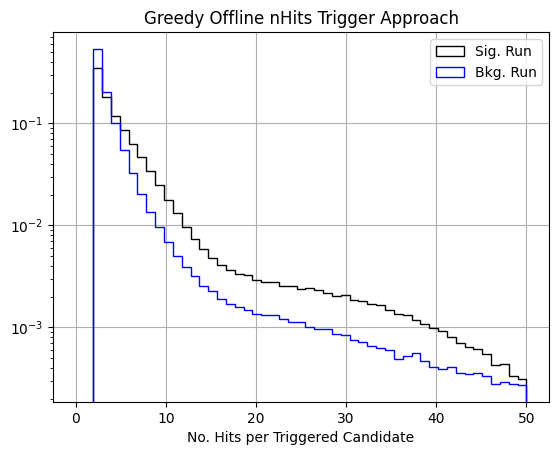

In [20]:
# subplot = pltext.canvas(2)

# subplot(1)
# pltext.hist(trms_sig, 1000, density=True);
# pltext.hist(trms_bkg, 1000, density=True);

# subplot(2)
pltext.hist(nhit_sig, 51, density=True, xylabels="No. Hits per Triggered Candidate", range=(0,50), stats=False, label="Sig. Run", ylog=True);
pltext.hist(nhit_bkg, 51, density=True, xylabels="No. Hits per Triggered Candidate", range=(0,50), stats=False, label="Bkg. Run", ylog=True);

plt.title("Greedy Offline nHits Trigger Approach");

In [5]:
mask_nhits_sig = nhit_sig <= 20
mask_nhits_bkg = nhit_bkg <= 20

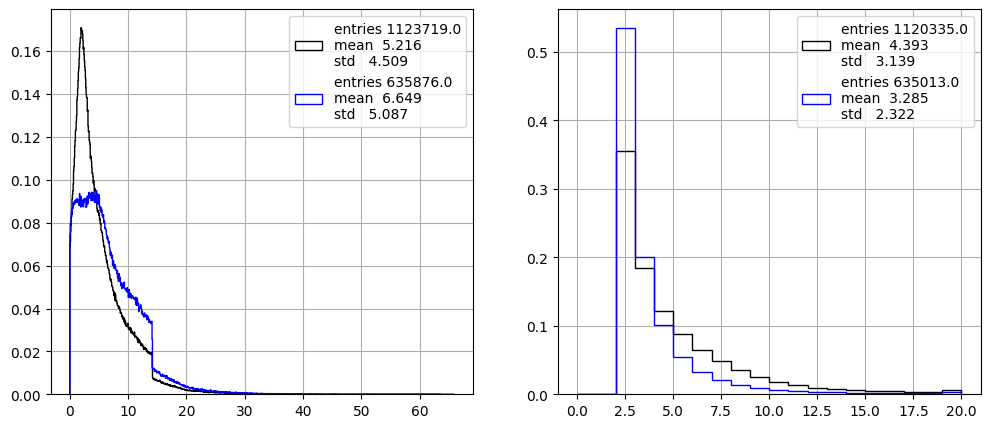

In [6]:
subplot = pltext.canvas(2)

subplot(1)
pltext.hist(trms_sig[mask_nhits_sig], 1000, density=True);
pltext.hist(trms_bkg[mask_nhits_bkg], 1000, density=True);

subplot(2)
pltext.hist(nhit_sig, 20, density=True, range=(0, 20));
pltext.hist(nhit_bkg, 20, density=True, range=(0, 20));

# ToF Correction

In [7]:
import json

# --- Load PMT positions from JSON ---
with open("/home/usc/ie/dcr/hk/ambe_analysis/AmBe_Data_Analysis/data/wcte_v11_20250513.json", "r") as f:
    geo_data = json.load(f)

# Build pmt_id → (x, y, z) map
mpmt_data = geo_data.get("mpmts", {})
pmt_positions = {}

for mpmt_idx in sorted(mpmt_data.keys(), key=int):
    mpmt = mpmt_data[mpmt_idx]
    pmts = mpmt.get("pmts", {})
    for pmt_idx in sorted(pmts.keys(), key=int):
        pmt = pmts[pmt_idx]
        location = pmt["placement"]["location"]
        pmt_id = int(mpmt_idx) * 19 + int(pmt_idx)
        pmt_positions[pmt_id] = np.array(location, dtype=np.float64)

print(f"Loaded {len(pmt_positions)} PMT positions")

# --- Source position and light speed in water ---
source = np.array([0, 1525, 0], dtype=np.float64)  # mm
c_water = 3e8 / 1.33  # m/s
c_water_mm_ns = c_water * 1e-6  # mm/ns

# --- Precompute ToF from source to every PMT ---
tof_map = {}
for pmt_id, pos in pmt_positions.items():
    dist = np.linalg.norm(pos - source)
    tof_map[pmt_id] = dist / c_water_mm_ns  # ns

Loaded 2014 PMT positions


In [8]:
# --- Apply ToF correction ---
df_sig["hit_pmt_calibrated_times_tof_corrected_source"] = (
    df_sig["hit_pmt_calibrated_times"] - df_sig["pmt_id"].map(tof_map)
)

print(f"Corrected {df_sig['hit_pmt_calibrated_times_tof_corrected_source'].notna().sum()} / {len(df_sig)} hits")
print(f"Missing PMT IDs: {df_sig['hit_pmt_calibrated_times_tof_corrected_source'].isna().sum()}")

# --- Apply ToF correction ---
df_bkg["hit_pmt_calibrated_times_tof_corrected_source"] = (
    df_bkg["hit_pmt_calibrated_times"] - df_bkg["pmt_id"].map(tof_map)
)

print(f"Corrected {df_bkg['hit_pmt_calibrated_times_tof_corrected_source'].notna().sum()} / {len(df_bkg)} hits")
print(f"Missing PMT IDs: {df_bkg['hit_pmt_calibrated_times_tof_corrected_source'].isna().sum()}")

Corrected 21251625 / 21251625 hits
Missing PMT IDs: 0
Corrected 16827396 / 16827396 hits
Missing PMT IDs: 0


# tRMS Again

In [9]:
trms_sig                      = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values
trms_sig_tof_corrected_source = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source"].std().values
trms_bkg                      = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].std().values
trms_bkg_tof_corrected_source = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source"].std().values

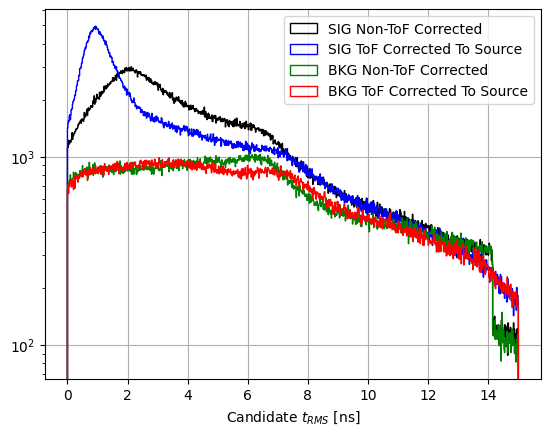

In [ ]:
pltext.hist(trms_sig                     , 1000, range=(0,15), xylabels="Candidate $t_{RMS}$ [ns]", stats=False, ylog=True, label="SIG Non-ToF Corrected");
pltext.hist(trms_sig_tof_corrected_source, 1000, range=(0,15), xylabels="Candidate $t_{RMS}$ [ns]", stats=False, ylog=True, label="SIG ToF Corrected To Source");
pltext.hist(trms_bkg                     , 1000, range=(0,15), xylabels="Candidate $t_{RMS}$ [ns]", stats=False, ylog=True, label="BKG Non-ToF Corrected");
pltext.hist(trms_bkg_tof_corrected_source, 1000, range=(0,15), xylabels="Candidate $t_{RMS}$ [ns]", stats=False, ylog=True, label="BKG ToF Corrected To Source");

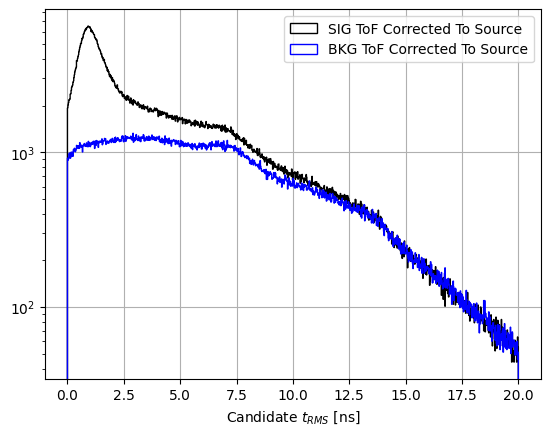

In [103]:
pltext.hist(trms_sig_tof_corrected_source, 1000, range=(0,20), xylabels="Candidate $t_{RMS}$ [ns]", stats=False, ylog=True, label="SIG ToF Corrected To Source");
pltext.hist(trms_bkg_tof_corrected_source, 1000, range=(0,20), xylabels="Candidate $t_{RMS}$ [ns]", stats=False, ylog=True, label="BKG ToF Corrected To Source");

In [12]:
df_sig["trms"] = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times"].transform("std")
df_sig["trms_tof_source"] = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source"].transform("std")

df_bkg["trms"] = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times"].transform("std")
df_bkg["trms_tof_source"] = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source"].transform("std")

# Desplegables

(2014,)
(2014,)


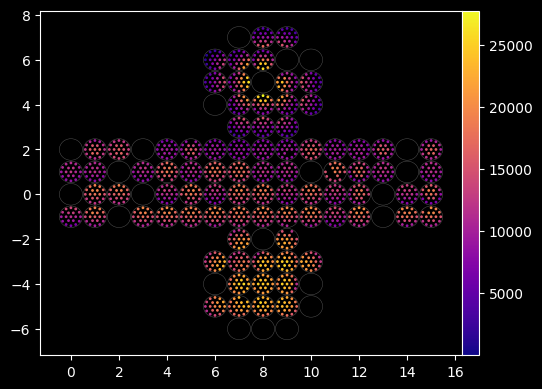

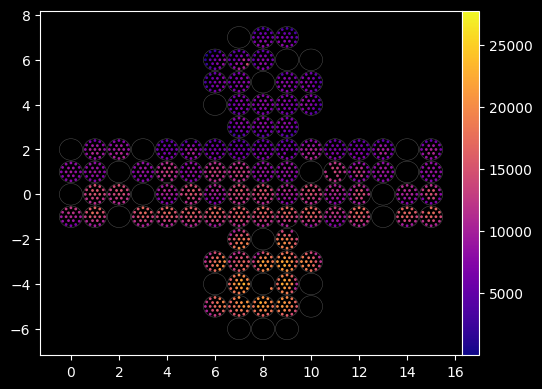

In [13]:
from WCTE_event_display.EventDisplay import EventDisplay
import matplotlib.colors as colors

#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")
import matplotlib.colors as colors

n_pmts = 2014

# --- Calculamos la escala global según df_sig ---
nhits_sig = df_sig.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
vmin = 1e-1  # mínimo positivo para LogNorm (evitar log(0))
vmax = nhits_sig.max()  # máximo para escalar

# --- df_sig ---
eventDisplay.plotEventDisplay(
    nhits_sig,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# --- df_bkg ---
nhits_bkg = df_bkg.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_bkg,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)

plt.style.use('default');
pltext.style()

(2014,)
(2014,)


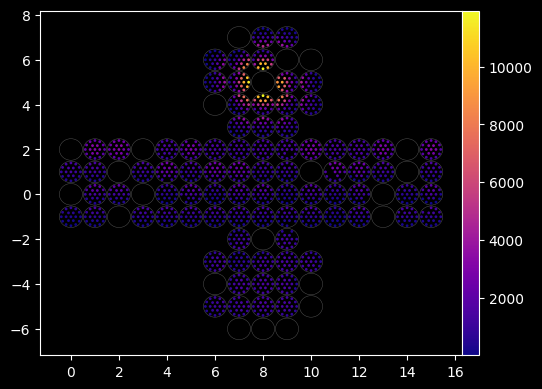

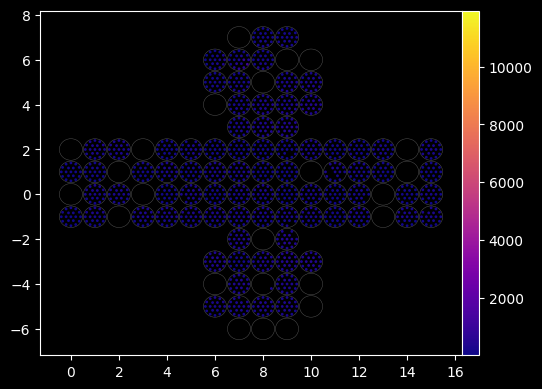

In [55]:
n_pmts = 2014

# --- Calculamos la escala global según df_sig ---
nhits_sig = df_sig[df_sig["trms_tof_source"].values < 2].groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
vmin = 1e-1  # mínimo positivo para LogNorm (evitar log(0))
vmax = nhits_sig.max()  # máximo para escalar

# --- df_sig ---
eventDisplay.plotEventDisplay(
    nhits_sig,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# --- df_bkg ---
nhits_bkg = df_bkg[df_bkg["trms_tof_source"].values < 2].groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_bkg,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)

plt.style.use('default');
pltext.style()

# Charge Calibration

In [57]:
df_sig_cut = df_sig[df_sig["trms_tof_source"].values < 2]
df_bkg_cut = df_bkg[df_bkg["trms_tof_source"].values < 2]

In [58]:
subplot = pltext.canvas(19)
mean_charge = []
mean_charge_err = []
for pmt in tqdm(range(2014), total=2014):
    charge = df_sig_cut[(df_sig_cut["pmt_id"].values == pmt)]["hit_pmt_charges"].values
    # subplot(pmt+1)
    # pltext.hist(charge, 100, range=(0, 1e3), stats=False, xylabels=f"Hit Charge In PMT #{pmt} [ADC]");
    try:
        h = pltext.hfit(charge, 100, "gaus", range=(75,210));
    except:
        mean_charge.append(np.nan)
        mean_charge_err.append(np.nan)
        continue
    plt.close()
    mean_charge.append(h[3][1])
    mean_charge_err.append(h[4][1])

100%|██████████| 2014/2014 [00:52<00:00, 38.14it/s]


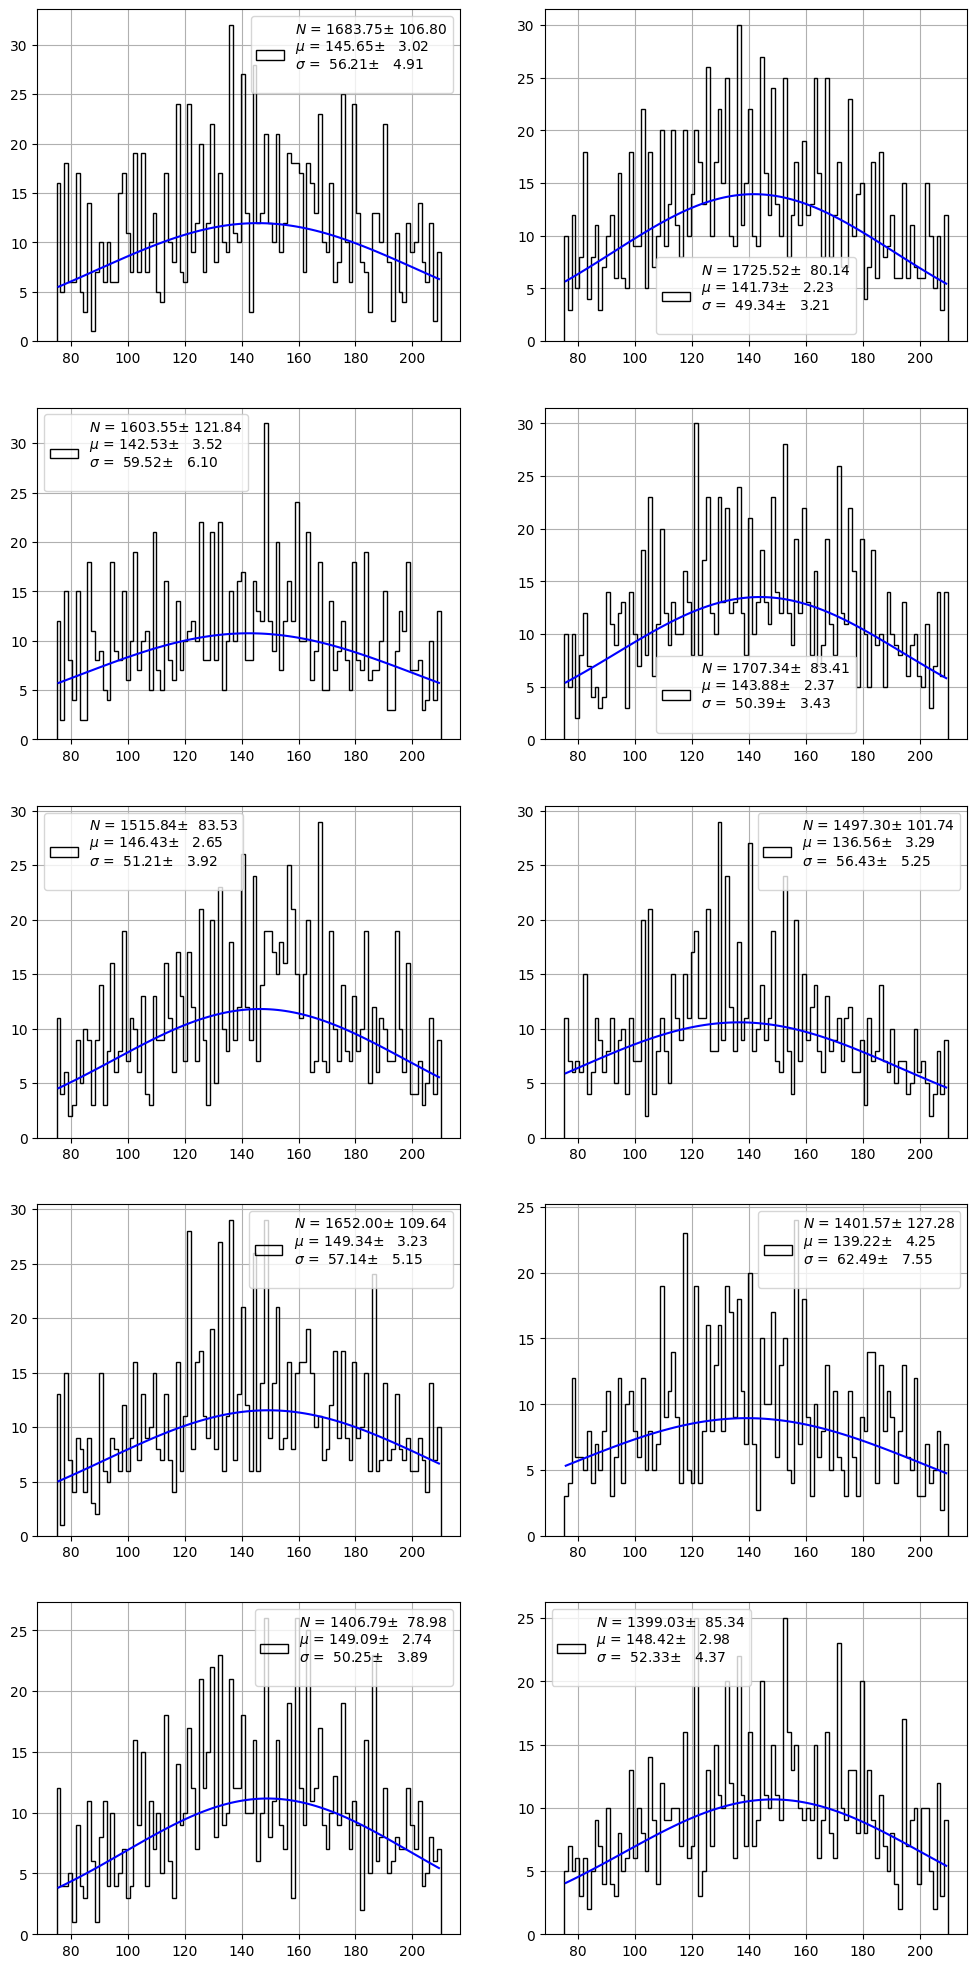

In [59]:
subplot = pltext.canvas(10)
for pmt in range(10):
    charge = df_sig_cut[df_sig_cut["pmt_id"].values == pmt]["hit_pmt_charges"].values
    subplot(pmt+1)
    # pltext.hist(charge, 100, range=(0, 1e3), stats=False, xylabels=f"Hit Charge In PMT #{pmt} [ADC]");
    try:
        h = pltext.hfit(charge, 100, "gaus", range=(75, 210));
    except:
        continue
    

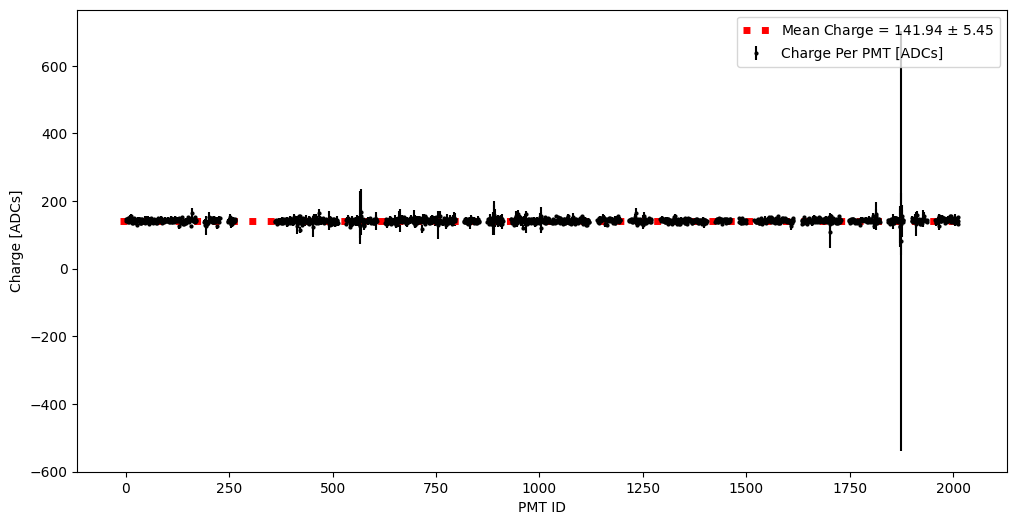

In [60]:
fig = plt.figure(figsize=(12, 6))
plt.errorbar(range(2014), mean_charge, yerr=mean_charge_err, fmt='o', markersize=2, label="Charge Per PMT [ADCs]");
# plt.ylim(110, 175);
plt.hlines(np.nanmean(mean_charge), -15, 2029, linestyles=":", color="red", linewidth=5,label=f"Mean Charge = {np.nanmean(mean_charge):.2f} $\pm$ {np.nanmean(mean_charge_err):.2f}");
plt.xlabel("PMT ID");
plt.ylabel("Charge [ADCs]");
plt.legend();

In [61]:
subplot = pltext.canvas(19)
mean_charge = []
mean_charge_err = []
for pmt in tqdm(range(2014), total=2014):
    charge = df_sig_cut[df_sig_cut["pmt_id"].values == pmt]["hit_pmt_charges"].values
    # subplot(pmt+1)
    # pltext.hist(charge, 100, range=(0, 1e3), stats=False, xylabels=f"Hit Charge In PMT #{pmt} [ADC]");
    try:
        h = pltext.hfit(charge, 100, "gaus", range=(50, 250));
    except:
        mean_charge.append(np.nan)
        mean_charge_err.append(np.nan)
        continue
    plt.close()
    mean_charge.append(h[3][1])
    mean_charge_err.append(h[4][1])

100%|██████████| 2014/2014 [00:47<00:00, 42.00it/s]


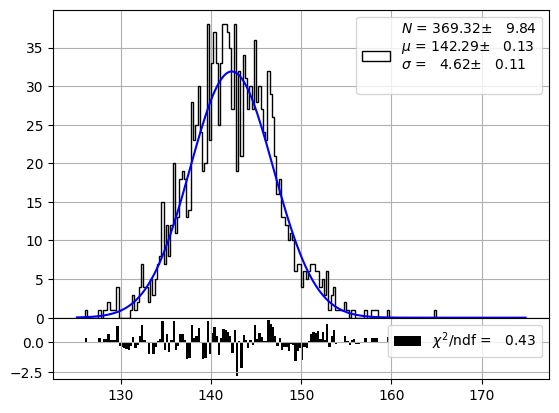

In [62]:
# pltext.hist([i for i in mean_charge if i!=0], 1000);
pltext.hfit(mean_charge, 200, 'gaus', range=(125, 175), residuals=True, xylabels="Mean Charge Per PMT [ADC]");

# Purity

In [39]:
valid_events = df_bkg["event_id"].unique()

noCandiates_sig = (
    df_sig[df_sig["event_id"].isin(valid_events)]
    .groupby("event_id")["candidate_id"]
    .nunique()
)

noCandiates_bkg = (
    df_bkg.groupby("event_id")["candidate_id"]
    .nunique()
)

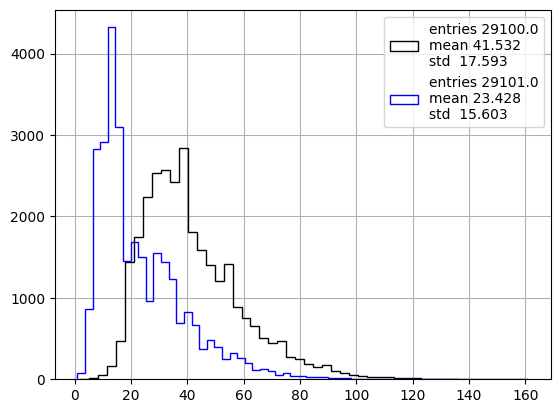

In [43]:
h_sig = pltext.hist(noCandiates_sig, 50);
h_bkg = pltext.hist(noCandiates_bkg, 50);

In [48]:
(np.mean(noCandiates_sig) - np.mean(noCandiates_bkg))/np.mean(noCandiates_sig)*100

np.float64(43.5919896363072)

In [63]:
valid_events = df_bkg_cut["event_id"].unique()

noCandiates_sig = (
    df_sig_cut[(df_sig_cut["event_id"].isin(valid_events))]
    .groupby("event_id")["candidate_id"]
    .nunique()
)

noCandiates_bkg = (
    df_bkg_cut.groupby("event_id")["candidate_id"]
    .nunique()
)

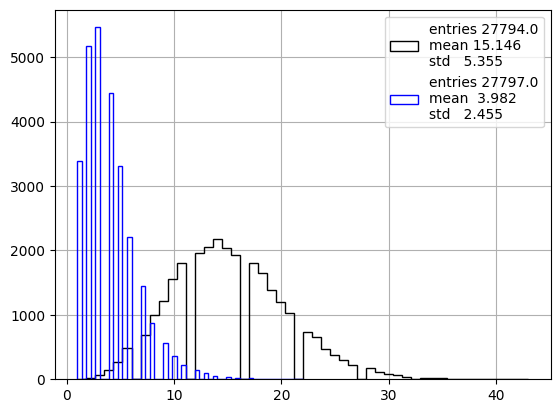

In [64]:
h_sig = pltext.hist(noCandiates_sig, 50);
h_bkg = pltext.hist(noCandiates_bkg, 50);

In [65]:
(np.mean(noCandiates_sig) - np.mean(noCandiates_bkg))/np.mean(noCandiates_sig)*100

np.float64(73.70618985684759)

# tc

In [78]:
df_sig["hit_pmt_calibrated_times_tof_corrected_source_shifted"] = df_sig["hit_pmt_calibrated_times_tof_corrected_source"].values - df_sig.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source"].transform("min").values
df_bkg["hit_pmt_calibrated_times_tof_corrected_source_shifted"] = df_bkg["hit_pmt_calibrated_times_tof_corrected_source"].values - df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source"].transform("min").values

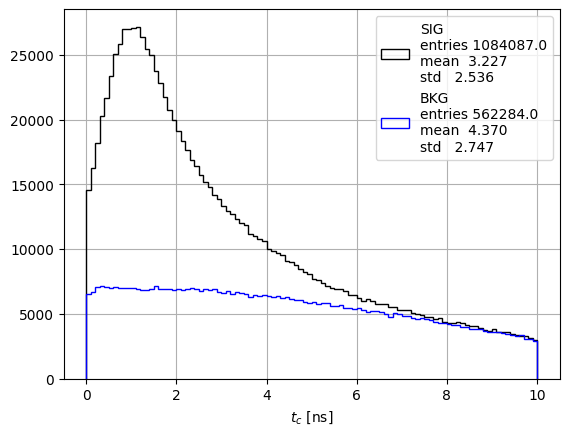

In [92]:
tc_shifted_sig = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source_shifted"].mean().values
tc_shifted_bkg = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source_shifted"].mean().values

pltext.hist(tc_shifted_sig, 100, range=(0, 10), xylabels="$t_c$ [ns]", label="SIG");
pltext.hist(tc_shifted_bkg, 100, range=(0, 10), xylabels="$t_c$ [ns]", label="BKG");

In [93]:
df_sig_cut["tc_shifted"] = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source_shifted"].transform("mean")
df_bkg_cut["tc_shifted"] = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source_shifted"].transform("mean")

/tmp/ipykernel_2077019/272855163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sig_cut["tc_shifted"] = df_sig.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source_shifted"].transform("mean")
/tmp/ipykernel_2077019/272855163.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bkg_cut["tc_shifted"] = df_bkg.groupby("candidate_id")["hit_pmt_calibrated_times_tof_corrected_source_shifted"].transform("mean")


# Purity Again

In [98]:
df_sig_cut_cut = df_sig_cut[df_sig_cut["tc_shifted"].values < 4]
df_bkg_cut_cut = df_bkg_cut[df_bkg_cut["tc_shifted"].values < 4]

In [99]:
valid_events = df_bkg_cut_cut["event_id"].unique()

noCandiates_sig = (
    df_sig_cut_cut[(df_sig_cut_cut["event_id"].isin(valid_events))]
    .groupby("event_id")["candidate_id"]
    .nunique()
)

noCandiates_bkg = (
    df_bkg_cut_cut.groupby("event_id")["candidate_id"]
    .nunique()
)

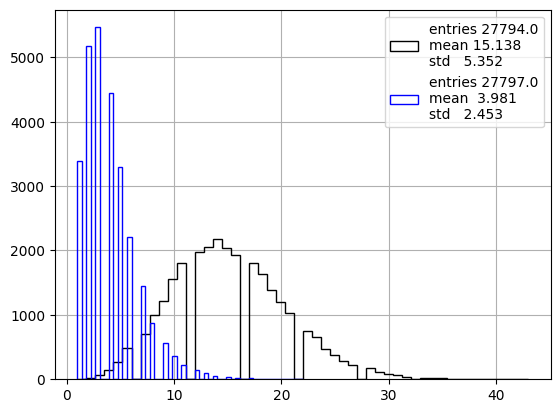

In [100]:
h_sig = pltext.hist(noCandiates_sig, 50);
h_bkg = pltext.hist(noCandiates_bkg, 50);

In [101]:
(np.mean(noCandiates_sig) - np.mean(noCandiates_bkg))/np.mean(noCandiates_sig)*100

np.float64(73.70422341213342)